# 3.4 UQ GPU\n
This notebook mirrors the UQ study from 3.3 and adds:\n
- device switch (`USE_GPU`)\n
- parallel seed execution (`PARALLEL_RUNS`)\n
- GPU/CPU aggregation of bin statistics via PyTorch\n

In [3]:
"""

Design
------
- FD grid is used as a coordinate scaffold only. Candidate points are
  drawn from FD grid coordinates so coverage is always dense.
- u values at interior points are computed by PDE-informed interpolation,
  NOT copied from FD. FD is used only for error measurement.
- Stopping criterion: max_points successfully computed interior points.
- KDTree for O(log N) neighbour queries.
- O(1) candidate removal via swap-and-pop.
"""

import time
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator

# ── PDE parameters ────────────────────────────────────────────────────────────
alpha = 0.05
c     = 0.5
T     = 1

def u_true(x, t):
    """Exact solution — replace with your actual IC/BC."""
    return np.sin(np.pi * x) * np.exp(-(alpha * np.pi**2 + c) * t)


# ── FD reference grid ─────────────────────────────────────────────────────────
nx_fd = 250
x_fd  = np.linspace(0.0, 1.0, nx_fd)
dx_fd = x_fd[1] - x_fd[0]

# Compute nt_fd from CFL — never touch this manually
dt_cfl = min(0.9  * dx_fd / c,
             0.45 * dx_fd**2 / alpha)
nt_fd  = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt_fd)
dt_fd  = t_fd[1] - t_fd[0]



def build_fd_reference():
    """Explicit upwind FD solve. Returns (u_fd, interpolant)."""
    u = np.zeros((nx_fd, nt_fd))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt_fd / dx_fd**2
    r_adv  = c     * dt_fd / dx_fd

    for it in range(nt_fd - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         - r_adv  * (un[1:-1] - un[:-2])
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,  it+1] = 0.0
        u[-1, it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
        bounds_error=False, fill_value=None
    )
    return u, interp


# ── Integrator hyperparameters ────────────────────────────────────────────────
max_points    = 10000   # stopping criterion
u_bound = 1.1
n_neighbours  = 5       # stencil size (3 equations, 5 unknowns → underdetermined)
cond_max      = 1e4
isotropy_max  = 50.0
w_max_factor  = 3.0     # reject if max|w_j| > w_max_factor / n
w_min_floor   = -1.0

# Spawn box in FD grid steps
spawn_nx      = 5       # ± x steps around a newly solved point
spawn_nt      = 3       # + t steps forward

# Neighbour search box in normalised units (x/dx_fd, t/dt_fd)
box_n0        = 2.0     # initial half-width
box_grow      = 1.5
box_nmax      = 15.0

max_candidates = 10_000


# ── KDTree-backed visited set ─────────────────────────────────────────────────
class VisitedSet:
    """
    Stores (x, t, u) points. KDTree is in normalised (x/dx_fd, t/dt_fd)
    space so both axes are commensurate during neighbour search.
    Rebuilt lazily every rebuild_every insertions.
    """
    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every

    def add(self, x, t, u):
        self._pts.append((x, t, u))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()

    def _rebuild(self):
        norm        = np.array([[p[0]/dx_fd, p[1]/dt_fd] for p in self._pts])
        self._tree  = KDTree(norm)
        self._dirty = 0

    def _ensure(self):
        if self._tree is None or self._dirty > 0:
            self._rebuild()

    def find_neighbours(self, x_star, t_star):
        """
        Expanding normalised-box search.
        Returns list of n_neighbours (x, t, u) tuples, or None.
        """
        self._ensure()
        xn = x_star / dx_fd
        tn = t_star / dt_fd
        bn = box_n0

        while True:
            idxs = self._tree.query_ball_point([xn, tn], r=bn, p=np.inf)
            nb = [
                self._pts[i] for i in idxs
                if abs(self._pts[i][0] - x_star) <= bn * dx_fd
                and 0 < (t_star - self._pts[i][1]) <= bn * dt_fd
            ]
            if len(nb) >= n_neighbours:
                nb.sort(key=lambda p: (p[0]-x_star)**2 + (p[1]-t_star)**2)
                return nb[:n_neighbours]

            bn = min(bn * box_grow, box_nmax)
            if bn >= box_nmax:
                return None

    def is_too_close(self, x, t, tol=0.4):
        """True if (x,t) is within tol grid cells of any visited point."""
        self._ensure()
        idxs = self._tree.query_ball_point([x/dx_fd, t/dt_fd], r=tol, p=np.inf)
        return len(idxs) > 0

    def __len__(self):
        return len(self._pts)


# ── Stencil geometry check ────────────────────────────────────────────────────
def stencil_is_good(dx_i, dt_i):
    if np.min(dx_i) * np.max(dx_i) > 0:          # two-sided coverage
        return False
    if np.max(dx_i) - np.min(dx_i) < 0.9 * dx_fd: # minimum span
        return False
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)
    pts = np.column_stack([dx_i / h, dt_i / tau])
    ev  = np.linalg.eigvalsh(pts.T @ pts)
    if ev[0] < 1e-14 or ev[1] / ev[0] > isotropy_max:
        return False
    return True


# ── Weight solver ─────────────────────────────────────────────────────────────
def solve_weights(dx_i, dt_i):
    """
    Min-norm lstsq on the 3×n PDE-informed system.
    Returns (w, cond) or (None, cond).
    """
    h   = max(np.max(np.abs(dx_i)), 1e-12)
    tau = max(np.max(np.abs(dt_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        (dx_i - c * dt_i)              / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])  # (3, n)
    b = np.array([1.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    if cond > cond_max:
        return None, cond

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    if abs(np.sum(w) - 1.0) > 1e-6:                    # partition of unity
        return None, cond
    if np.max(np.abs(w)) > w_max_factor / len(dx_i):   # no dominant weight
        return None, cond
    if np.min(w) < w_min_floor:                         # no extreme negatives
        return None, cond

    return w, cond


# ── Main integrator ───────────────────────────────────────────────────────────
def run_integrator(seed=None):
    t_wall = time.time()
    if seed is not None:
        np.random.seed(seed)

    print("Building FD reference...", flush=True)
    _, fd_interp = build_fd_reference()
    print(f"  dx={dx_fd:.4f}  dt={dt_fd:.5f}", flush=True)

    # IC + BC into visited set
    visited = VisitedSet()
    for ix in range(nx_fd):
        visited.add(x_fd[ix], 0.0, u_true(x_fd[ix], 0.0))
    for it in range(1, nt_fd):
        visited.add(0.0,  t_fd[it], 0.0)
        visited.add(1.0,  t_fd[it], 0.0)
    print(f"  IC+BC points: {len(visited)}", flush=True)

    # Candidate pool — integer (ix, it) keys for O(1) deduplication
    cand_keys = set()
    cand_list = []   # list of (x, t)

    def push(ix, it):
        if (ix, it) not in cand_keys:
            cand_keys.add((ix, it))
            cand_list.append((x_fd[ix], t_fd[it]))

    # Seed from IC
    for ix in range(1, nx_fd - 1):
        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix, nit = ix + dix, dit
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push(nix, nit)

    print(f"  Initial candidates: {len(cand_list)}", flush=True)
    print(f"  Stopping at {max_points} computed points\n", flush=True)

    rej        = dict(proximity=0, no_nb=0, geometry=0, cond=0, weights=0)
    point_data = []

    while cand_list and len(point_data) < max_points:

        # Trim if candidate list is over budget
        if len(cand_list) > max_candidates:
            del cand_list[:len(cand_list) - max_candidates]

        # ── O(1) swap-and-pop ─────────────────────────────────────────────
        idx            = np.random.randint(len(cand_list))
        x_star, t_star = cand_list[idx]
        cand_list[idx] = cand_list[-1]
        cand_list.pop()
        ix_s = int(round(x_star / dx_fd))
        it_s = int(round(t_star / dt_fd))
        cand_keys.discard((ix_s, it_s))
        # ─────────────────────────────────────────────────────────────────

        if visited.is_too_close(x_star, t_star):
            rej['proximity'] += 1
            continue

        nb = visited.find_neighbours(x_star, t_star)
        if nb is None:
            rej['no_nb'] += 1
            continue

        nb_pts = np.array(nb)
        dx_i   = nb_pts[:, 0] - x_star
        dt_i   = nb_pts[:, 1] - t_star   # negative: neighbours are in the past

        if not stencil_is_good(dx_i, dt_i):
            rej['geometry'] += 1
            continue

        w, cond = solve_weights(dx_i, dt_i)
        if w is None:
            rej['cond' if cond > cond_max else 'weights'] += 1
            continue

        # ── Accept point ──────────────────────────────────────────────────
        u_hat = float(w @ nb_pts[:, 2])

        # Break the error cascade — u is bounded by IC amplitude + margin
        if abs(u_hat) > u_bound:
            rej['bounds'] = rej.get('bounds', 0) + 1
            continue

        visited.add(x_star, t_star, u_hat)

        # Spawn new candidates in the FD grid box around this point
        for dix in range(-spawn_nx, spawn_nx + 1):
            for dit in range(1, spawn_nt + 1):
                nix = ix_s + dix
                nit = it_s + dit
                if 1 <= nix <= nx_fd - 2 and nit < nt_fd:
                    push(nix, nit)

        u_ref = float(fd_interp([[x_star, t_star]])[0])
 
        point_data.append({
            'x':     x_star,
            't':     t_star,
            'u':     u_hat,
            'err':   abs(u_hat - u_ref),
            'cond':  cond,
            'w1':    float(np.sum(np.abs(w))),
            'box_x': float(np.max(np.abs(dx_i))),   # ← add this
            'box_t': float(np.max(np.abs(dt_i))),   # ← add this
            'nb_x':  nb_pts[:, 0].copy(),            # ← add
            'nb_t':  nb_pts[:, 1].copy(),            # ← add
            'nb_u':  nb_pts[:, 2].copy(),            # ← add
        })

        if len(point_data) % 500 == 0:
            errs = [p['err'] for p in point_data]
            t_max = max(p['t'] for p in point_data)
            print(f"  {len(point_data):5d} pts | "
                  f"mean={np.mean(errs):.2e} | "
                  f"max={np.max(errs):.2e} | "
                  f"t_max={t_max:.3f} | "
                  f"cands={len(cand_list):5d} | "
                  f"wall={time.time()-t_wall:.1f}s",
                  flush=True)

    # ── Summary ───────────────────────────────────────────────────────────────
    errs = np.array([p['err'] for p in point_data])
    print(f"\n{'─'*56}")
    print(f"  Computed  : {len(point_data)} points")
    print(f"  Mean err  : {errs.mean():.3e}")
    print(f"  Max  err  : {errs.max():.3e}")
    print(f"  Wall time : {time.time()-t_wall:.1f}s")
    total = sum(rej.values()) + len(point_data)
    print(f"\n  Rejections (total attempts: {total})")
    for r, n in rej.items():
        print(f"    {r:10s}: {n:6d}  ({100*n/total:.1f}%)")

    return visited, point_data, fd_interp


Device       : cuda
Parallel runs: True
Workers      : 5

Running 5 integrations (4000 pts each)...

Building FD reference...
Building FD reference...
Building FD reference...
Building FD reference...
  dx=0.0040  dt=0.00015
Building FD reference...
  dx=0.0040  dt=0.00015
  dx=0.0040  dt=0.00015
  dx=0.0040  dt=0.00015
  dx=0.0040  dt=0.00015
  IC+BC points: 14030  IC+BC points: 14030

  Initial candidates: 744
  Initial candidates: 744
  Stopping at 4000 computed points

  Stopping at 4000 computed points
  IC+BC points: 14030
  IC+BC points: 14030

  Initial candidates: 744  Initial candidates: 744

  IC+BC points: 14030
  Stopping at 4000 computed points
  Initial candidates: 744
  Stopping at 4000 computed points


  Stopping at 4000 computed points

    500 pts | mean=6.73e-06 | max=4.56e-05 | t_max=0.003 | cands= 3543 | wall=50.4s
    500 pts | mean=5.91e-06 | max=3.63e-05 | t_max=0.003 | cands= 3633 | wall=51.2s
    500 pts | mean=6.74e-06 | max=9.90e-05 | t_max=0.003 | cands= 

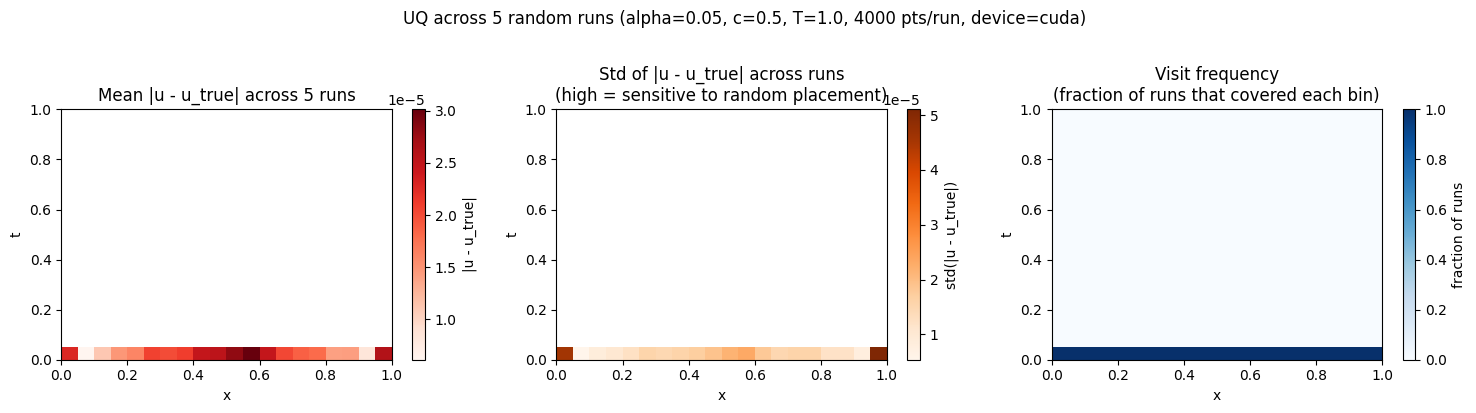


Across all 5 runs:
  Overall mean error : 1.907e-05
  Overall std error  : 2.012e-05
  Overall max error  : 5.720e-04

Bins never visited by any run : 380 / 400
Bins visited by all 5 runs: 20 / 400


In [4]:
"""
GPU-compatible UQ study (same outputs as 3.3 cell 5):
  1) Mean |u - u_true| per (x, t) bin
  2) Std(|u - u_true|) per bin
  3) Visit frequency per bin

Single switches:
  - USE_GPU: set False to force CPU
  - PARALLEL_RUNS: set False to run seeds sequentially
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
import torch

# =============================
# Single switches
# =============================
USE_GPU = True
PARALLEL_RUNS = True

# =============================
# UQ parameters
# =============================
n_runs = 5
uq_seeds = list(range(n_runs))
uq_max_points = 4_000
n_bins_x = 20
n_bins_t = 20

# Use the rollout horizon already defined by the integrator setup.
# If you want a different horizon only for binning/plots, set this to a float.
UQ_T_OVERRIDE = None

n_workers = min(os.cpu_count() or 1, n_runs)
device = torch.device('cuda' if (USE_GPU and torch.cuda.is_available()) else 'cpu')

print(f"Device       : {device}")
print(f"Parallel runs: {PARALLEL_RUNS}")
print(f"Workers      : {n_workers}\n")


def _run_one_seed(seed):
    visited_uq, pd_uq, _ = run_integrator(seed=seed)
    errs = np.array([p['err'] for p in pd_uq], dtype=float)
    return {
        'seed': seed,
        'point_data': pd_uq,
        'n': len(pd_uq),
        'mean': float(np.mean(errs)) if errs.size else np.nan,
        'max': float(np.max(errs)) if errs.size else np.nan,
    }


print(f"Running {n_runs} integrations ({uq_max_points} pts each)...\n")

_orig_max_points = max_points
all_point_data = []

try:
    max_points = uq_max_points

    if PARALLEL_RUNS and n_workers > 1:
        with ThreadPoolExecutor(max_workers=n_workers) as ex:
            futures = {ex.submit(_run_one_seed, s): s for s in uq_seeds}
            for fut in as_completed(futures):
                out = fut.result()
                all_point_data.append(out['point_data'])
                print(f"  seed {out['seed']:2d} | pts={out['n']:4d} | "
                      f"mean={out['mean']:.2e} | max={out['max']:.2e}")
    else:
        for s in uq_seeds:
            out = _run_one_seed(s)
            all_point_data.append(out['point_data'])
            print(f"  seed {out['seed']:2d} | pts={out['n']:4d} | "
                  f"mean={out['mean']:.2e} | max={out['max']:.2e}")
finally:
    max_points = _orig_max_points

if len(all_point_data) != len(uq_seeds):
    raise RuntimeError('Some UQ runs did not complete.')

# ========== Bin accumulation on selected device ==========
t_horizon = float(T if UQ_T_OVERRIDE is None else UQ_T_OVERRIDE)
dx_bin = 1.0 / n_bins_x
dt_bin = t_horizon / n_bins_t
num_bins = n_bins_x * n_bins_t

sum_err = torch.zeros(num_bins, dtype=torch.float64, device=device)
sum_sq = torch.zeros(num_bins, dtype=torch.float64, device=device)
count = torch.zeros(num_bins, dtype=torch.int64, device=device)
visit_counts = np.zeros(num_bins, dtype=np.int64)

for run_data in all_point_data:
    if len(run_data) == 0:
        continue

    x = torch.as_tensor([p['x'] for p in run_data], dtype=torch.float64, device=device)
    t = torch.as_tensor([p['t'] for p in run_data], dtype=torch.float64, device=device)
    e = torch.as_tensor([p['err'] for p in run_data], dtype=torch.float64, device=device)

    ix = torch.clamp((x / dx_bin).to(torch.int64), 0, n_bins_x - 1)
    it = torch.clamp((t / dt_bin).to(torch.int64), 0, n_bins_t - 1)
    lin = ix * n_bins_t + it

    ones = torch.ones_like(lin, dtype=torch.int64)
    count.scatter_add_(0, lin, ones)
    sum_err.scatter_add_(0, lin, e)
    sum_sq.scatter_add_(0, lin, e * e)

    visited_unique = torch.unique(lin).detach().cpu().numpy()
    visit_counts[visited_unique] += 1

mean_flat = torch.full((num_bins,), torch.nan, dtype=torch.float64, device=device)
std_flat = torch.full((num_bins,), torch.nan, dtype=torch.float64, device=device)

valid_mean = count > 0
mean_flat[valid_mean] = sum_err[valid_mean] / count[valid_mean].to(torch.float64)

valid_std = count > 1
var_flat = torch.full((num_bins,), torch.nan, dtype=torch.float64, device=device)
var_flat[valid_std] = (
    sum_sq[valid_std] / count[valid_std].to(torch.float64)
    - mean_flat[valid_std] ** 2
)
var_flat = torch.clamp(var_flat, min=0.0)
std_flat[valid_std] = torch.sqrt(var_flat[valid_std])

mean_err = mean_flat.reshape(n_bins_x, n_bins_t).detach().cpu().numpy()
std_err = std_flat.reshape(n_bins_x, n_bins_t).detach().cpu().numpy()
visit_freq = (visit_counts.reshape(n_bins_x, n_bins_t) / n_runs).astype(float)

x_edges = np.linspace(0.0, 1.0, n_bins_x + 1)
t_edges = np.linspace(0.0, t_horizon, n_bins_t + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))


def heatmap(ax, data, title, cmap, label):
    im = ax.pcolormesh(x_edges, t_edges, data.T, cmap=cmap, shading='flat')
    plt.colorbar(im, ax=ax, label=label)
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_title(title)


heatmap(
    axes[0],
    mean_err,
    f'Mean |u - u_true| across {n_runs} runs',
    'Reds',
    '|u - u_true|',
)

heatmap(
    axes[1],
    std_err,
    'Std of |u - u_true| across runs\n(high = sensitive to random placement)',
    'Oranges',
    'std(|u - u_true|)',
)

heatmap(
    axes[2],
    visit_freq,
    'Visit frequency\n(fraction of runs that covered each bin)',
    'Blues',
    'fraction of runs',
)

plt.suptitle(
    f'UQ across {n_runs} random runs '
    f'(alpha={alpha}, c={c}, T={t_horizon}, {uq_max_points} pts/run, device={device})',
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

all_errs = np.array([p['err'] for pd in all_point_data for p in pd], dtype=float)
print(f"\nAcross all {n_runs} runs:")
print(f"  Overall mean error : {np.mean(all_errs):.3e}")
print(f"  Overall std error  : {np.std(all_errs):.3e}")
print(f"  Overall max error  : {np.max(all_errs):.3e}")
print(
    f"\nBins never visited by any run : "
    f"{np.sum(visit_counts == 0)} / {num_bins}"
)
print(
    f"Bins visited by all {n_runs} runs: "
    f"{np.sum(visit_counts == n_runs)} / {num_bins}"
)
